In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Au fost detectate {len(gpus)} GPU-uri active:")
    for i, gpu in enumerate(gpus):
        print(f" Placa {i}: {gpu.name}")
else:
    print("Niciun GPU detectat. Sistemul rulează lent pe CPU.")


2026-04-16 07:15:32.054367: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776323732.452507      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776323732.565120      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776323733.533114      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776323733.533153      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776323733.533157      55 computation_placer.cc:177] computation placer alr

Au fost detectate 2 GPU-uri active:
 Placa 0: /physical_device:GPU:0
 Placa 1: /physical_device:GPU:1


In [2]:

strategy = tf.distribute.MirroredStrategy()
print(f"Numărul de unități grafice sincronizate: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Numărul de unități grafice sincronizate: 2


I0000 00:00:1776323797.090637      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776323797.096841      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# celula 1 realizeaza preprocesarea datelor + augumentare
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir= '/kaggle/input/datasets/prilia/fer2013pluscleanedaugmballanced1/train'
test_dir='/kaggle/input/datasets/prilia/fer2013pluscleanedaugmballanced1/test'

print ("Versiune TensorFlow: ", tf.__version__)
print ("Versiune Keras: ", keras.__version__)

img_size=48
batch_size=64
epoci = 50
num_classes= 7 
print ("\n partea de preprocesare si impartire a datelor")
datagen = ImageDataGenerator (
    featurewise_center=False,
    featurewise_std_normalization=False,
    rescale=1./255,
    rotation_range=10,
    zoom_range= 0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest',
    validation_split=0.20
)

test_datagen = ImageDataGenerator(rescale=1./255)

print("Setul de antrenare (80%):")
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",      
    batch_size=batch_size,
    class_mode='categorical',     
    shuffle=True                  
)

print("Setul de validare (20%):")
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,                
    subset='validation'           
)

print("Setul de testare:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Versiune TensorFlow:  2.19.0
Versiune Keras:  3.10.0

 partea de preprocesare si impartire a datelor
Setul de antrenare (80%):
Found 23251 images belonging to 7 classes.
Setul de validare (20%):
Found 4648 images belonging to 7 classes.
Setul de testare:
Found 5772 images belonging to 7 classes.


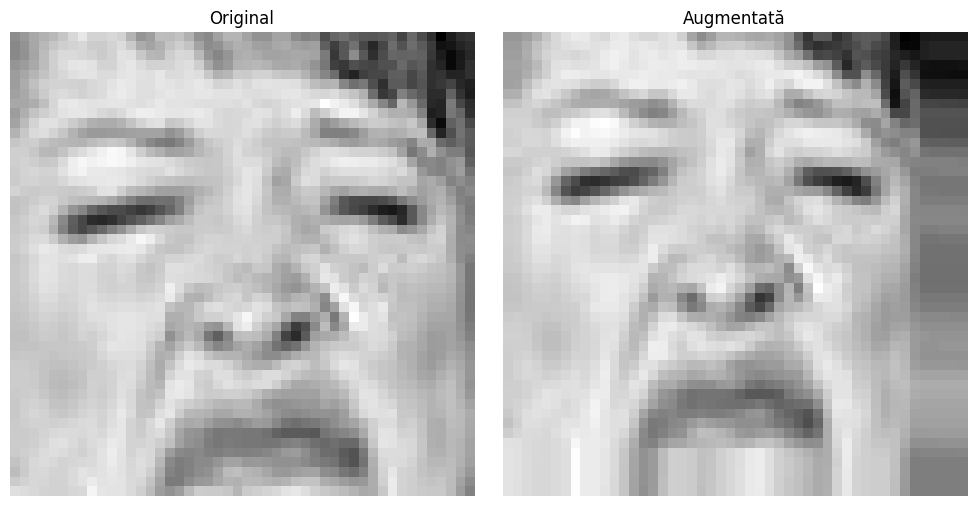

In [4]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

clase_disponibile = os.listdir(train_dir)
clasa_random = random.choice(clase_disponibile)
folder_clasa = os.path.join(train_dir, clasa_random)

imagini_disponibile = os.listdir(folder_clasa)
imagine_random = random.choice(imagini_disponibile)
cale_imagine = os.path.join(folder_clasa, imagine_random)

img = load_img(cale_imagine, target_size=(img_size, img_size), color_mode="grayscale")
img_originala = img_to_array(img)

img_augmentata = datagen.random_transform(img_originala)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title(f"Original")

plt.imshow(img_originala.reshape(img_size, img_size), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Augmentată")
plt.imshow(img_augmentata.reshape(img_size, img_size), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
train_class_labels=train_generator.class_indices
print("etichete antrenament : ",train_class_labels)

val_class_labels=val_generator.class_indices
print("etichete validare : ",val_class_labels)

test_class_labels=test_generator.class_indices
print("etichete test : ",test_class_labels)

etichete antrenament :  {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}
etichete validare :  {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}
etichete test :  {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}


In [7]:
#implementarea retelei de tip v-cnn 
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input,Activation, BatchNormalization
from keras.optimizers import Adam 

def creare_v_cnn_model(input_shape, num_classes, flat=1, fil=[64,128,256], nl=[1,1,1], hid=[128]):
    model= Sequential()
    csize= 3; stri=2;
    psiz=2
    drop1=0.3

    model.add(Conv2D(fil[0],padding='same', kernel_size=(csize,csize),input_shape=input_shape))
    model.add(Activation('relu'))
    
    for i in range(nl[0]):
        model.add(Conv2D(fil[0], padding='same', kernel_size=(csize, csize)))
        model.add(Activation('relu'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(psiz, psiz), strides=(stri, stri), padding='same'))
    model.add(Dropout(drop1))

    for layer in range(1, len(fil)):
        for j in range(nl[layer]):
            model.add(Conv2D(fil[layer], padding='same', kernel_size=(csize, csize)))
            model.add(Activation('relu'))
            
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(psiz, psiz), strides=(stri, stri), padding='same'))
        model.add(Dropout(drop1))

    if flat == 1:
        model.add(Flatten())
    else:
        model.add(GlobalAveragePooling2D())

    for h_size in hid:
        model.add(Dense(h_size, activation='relu'))
        model.add(Dropout(drop1))
    
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

print("Construim arhitectura V-CNN...")
with strategy.scope():
    model = creare_v_cnn_model(input_shape=(48, 48, 1), num_classes=7)

model.summary()

Construim arhitectura V-CNN...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,589,063 (6.06 MB)

 Trainable params: 1,588,167 (6.06 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
from keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint=ModelCheckpoint(
    "v_cnn_best_model.keras",
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True, 
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=8,               
    restore_best_weights=True,
    verbose=1
)


In [9]:
import time

t_start_train = time.time()
istoric_antrenare= model.fit(
    train_generator,
    epochs=epoci,
    validation_data=val_generator,
    callbacks=[checkpoint,early_stopping]
)
t_end_train = time.time()

t_start_test = time.time()
score=model.evaluate(test_generator, verbose=0)
t_end_test = time.time()

nr_total_poze= test_generator.samples

timp_antrenament_minute = int(t_end_train - t_start_train) / 60
timp_testare_secunde = t_end_test - t_start_test
latenta_ms = 1000 * timp_testare_secunde / nr_total_poze

epoci_rulate = len(istoric_antrenare.history['loss'])

print(' RAPORT DE PERFORMANȚĂ V-CNN')

print(f'Timp total antrenament ({epoci_rulate} epoci): {timp_antrenament_minute:.2f} minute')
print(f'Numărul total de parametri: {model.count_params()}')
print(f'Acuratețea finală pe setul de test: {score[1]*100:.2f} %')
print(f'Timpul total de predicție la test: {timp_testare_secunde:.4f} secunde')
print(f'Latența pe GPU (per cadru): {latenta_ms:.4f} ms')

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

E0000 00:00:1776323865.808216      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1776323866.839409     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776323867.814937     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.1844 - loss: 2.3362INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_accuracy improved from -inf to 0.18524, saving model to v_cnn_best_model.keras
364/364 ━━━━━━━━━━━━━━━━━━━━ 108s 274ms/step - accuracy: 0.1845 - loss: 2.3352 - val_accuracy: 0.1852 - val_loss: 1.9189
Epoch 2/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3022 - loss: 1.6845
Epoch 2: val_accuracy improved from 0.18524 to 0.38188, saving model to v_cnn_best_model.keras
364/364 ━━━━━━━━━━━━━━━━━━━━ 48s 132ms/step - accuracy: 0.3022 - loss: 1.6844 - val_accuracy: 0.3819 - val_loss: 1.5497
Epoch 3/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3603 - loss: 1.5311
Epoch 3: val_accuracy did not improve f

In [10]:
from tensorflow.keras.models import load_model
model = load_model('v_cnn_best_model.keras')

Calculăm predicțiile pe setul de test...
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step


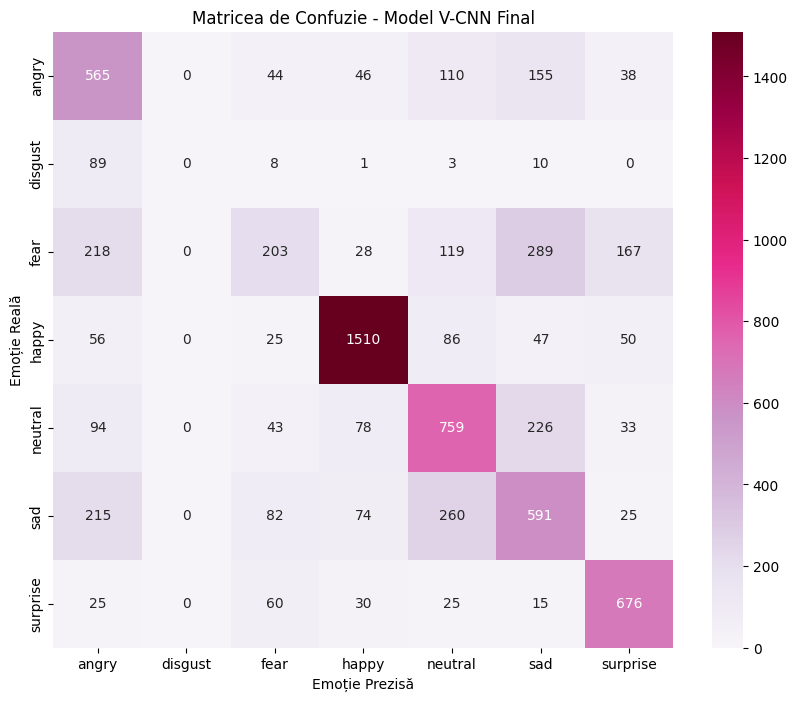


Raport de Clasificare Detaliat:

              precision    recall  f1-score   support

       angry       0.45      0.59      0.51       958
     disgust       0.00      0.00      0.00       111
        fear       0.44      0.20      0.27      1024
       happy       0.85      0.85      0.85      1774
     neutral       0.56      0.62      0.58      1233
         sad       0.44      0.47      0.46      1247
    surprise       0.68      0.81      0.74       831

    accuracy                           0.60      7178
   macro avg       0.49      0.51      0.49      7178
weighted avg       0.59      0.60      0.58      7178



In [17]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

test_generator.reset()

print("Calculăm predicțiile pe setul de test...")
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

etichete = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd', 
            xticklabels=etichete, yticklabels=etichete)
plt.title('Matricea de Confuzie - Model V-CNN Final')
plt.ylabel('Emoție Reală')
plt.xlabel('Emoție Prezisă')
plt.show()

print("\nRaport de Clasificare Detaliat:\n")
print(classification_report(y_true, y_pred, target_names=etichete, zero_division=0))

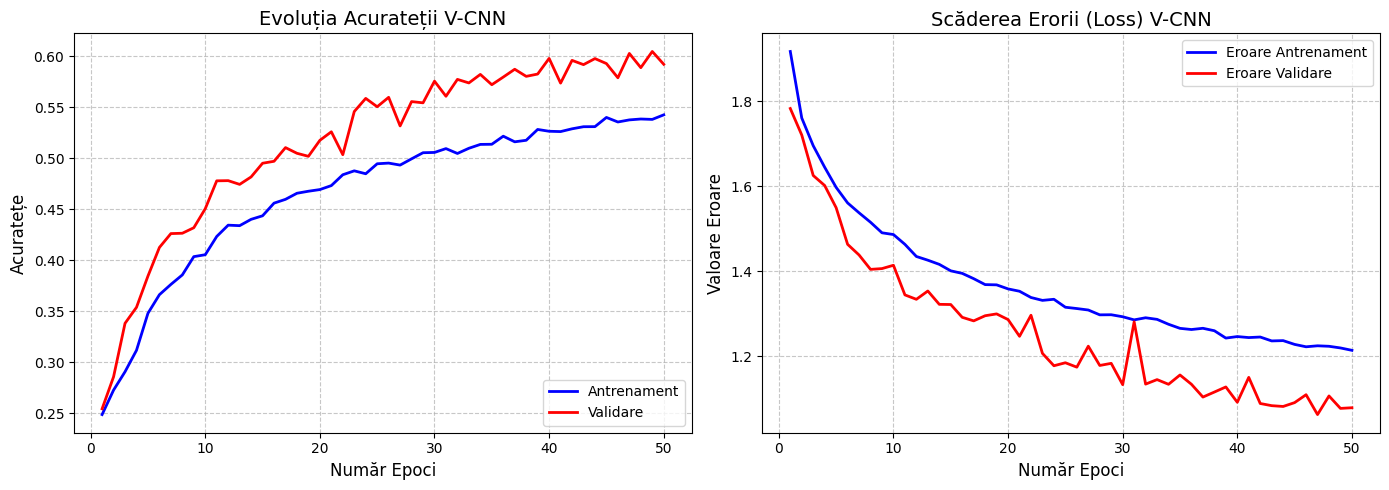

In [18]:
import matplotlib.pyplot as plt


acc = istoric_antrenare.history['accuracy']
val_acc = istoric_antrenare.history['val_accuracy']
loss = istoric_antrenare.history['loss']
val_loss = istoric_antrenare.history['val_loss']

epoci_rulate = range(1, len(acc) + 1)


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(epoci_rulate, acc, 'b-', linewidth=2, label='Antrenament')
plt.plot(epoci_rulate, val_acc, 'r-', linewidth=2, label='Validare')
plt.title('Evoluția Acurateții V-CNN', fontsize=14)
plt.xlabel('Număr Epoci', fontsize=12)
plt.ylabel('Acuratețe', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
plt.plot(epoci_rulate, loss, 'b-', linewidth=2, label='Eroare Antrenament')
plt.plot(epoci_rulate, val_loss, 'r-', linewidth=2, label='Eroare Validare')
plt.title('Scăderea Erorii (Loss) V-CNN', fontsize=14)
plt.xlabel('Număr Epoci', fontsize=12)
plt.ylabel('Valoare Eroare', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


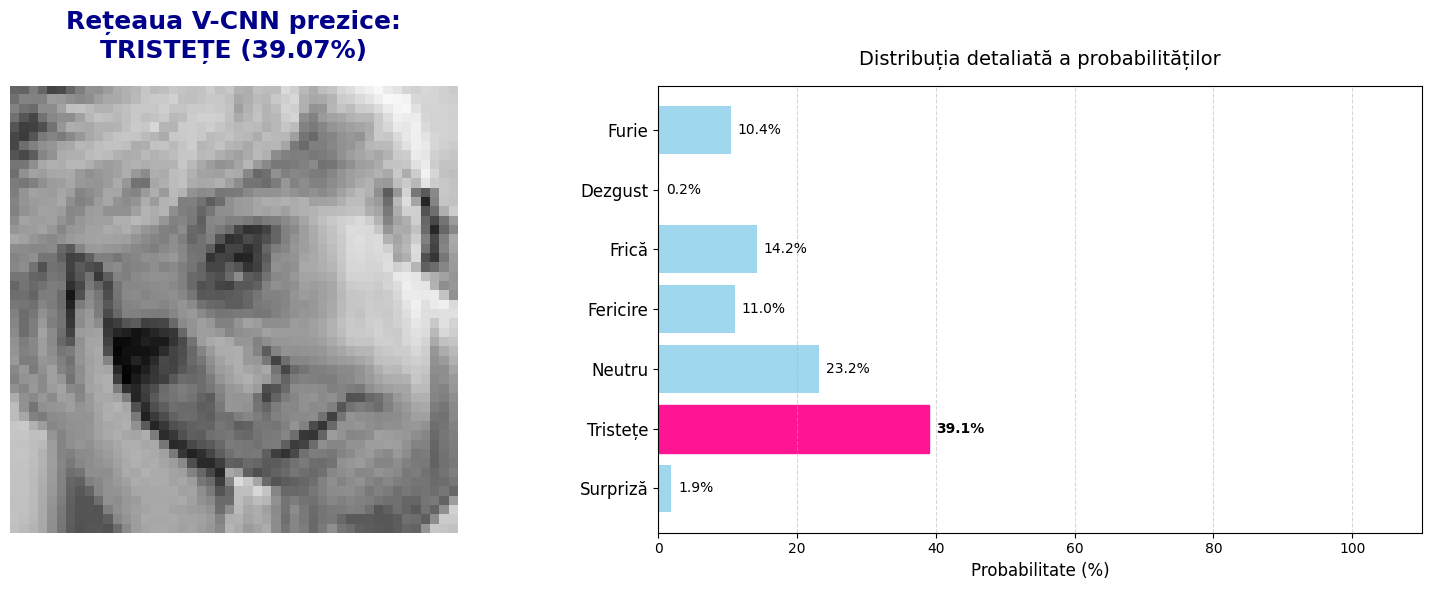

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def testeaza_cu_legenda(cale_imagine):
    
    etichete_en = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    
    clase_ro = {
        'angry': 'FURIE',
        'disgust': 'DEZGUST',
        'fear': 'FRICĂ',
        'happy': 'FERICIRE',
        'neutral': 'NEUTRU',
        'sad': 'TRISTEȚE',
        'surprise': 'SURPRIZĂ'
    }
    
    nume_ro_scurt = ['Furie', 'Dezgust', 'Frică', 'Fericire', 'Neutru', 'Tristețe', 'Surpriză']

    try:
        img_pt_model = image.load_img(cale_imagine, target_size=(48, 48), color_mode="grayscale")
    except Exception as e:
        print(f"Eroare la încărcarea imaginii: {e}")
        return

    img_array = image.img_to_array(img_pt_model)
    img_array = np.expand_dims(img_array, axis=0) 
    img_array /= 255.0 

    predictii_brute = model.predict(img_array)[0] 
    index_maxim = np.argmax(predictii_brute)
    
    emotie_w_en = etichete_en[index_maxim]
    emotie_w_ro = clase_ro[emotie_w_en]
    procent_w = predictii_brute[index_maxim] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    img_orig = cv2.imread(cale_imagine)
    if img_orig is None:
        print("Eroare: Nu am putut citi imaginea originală pentru afișare!")
        return
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    
    ax1.imshow(img_orig)
    ax1.axis('off') 
    
    culoare_titlu = 'green' if emotie_w_en == 'happy' else 'red' if emotie_w_en in ['angry', 'fear'] else 'darkblue'
    
    ax1.set_title(f"Rețeaua V-CNN prezice:\n{emotie_w_ro} ({procent_w:.2f}%)", 
                  fontsize=18, color=culoare_titlu, fontweight='bold', pad=20)

    y_pos = np.arange(len(nume_ro_scurt))
    procente_afisare = predictii_brute * 100
    
    bare = ax2.barh(y_pos, procente_afisare, align='center', color='skyblue', alpha=0.8)
    
    bare[index_maxim].set_color('deeppink')
    bare[index_maxim].set_alpha(1.0)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(nume_ro_scurt, fontsize=12)
    ax2.invert_yaxis() 
    ax2.set_xlabel('Probabilitate (%)', fontsize=12)
    ax2.set_title('Distribuția detaliată a probabilităților', fontsize=14, pad=15)
    
    for i, bar in enumerate(bare):
        latime = bar.get_width()
        ax2.text(latime + 1, bar.get_y() + bar.get_height()/2, 
                 f'{procente_afisare[i]:.1f}%', 
                 va='center', fontsize=10, fontweight='bold' if i == index_maxim else 'normal')

    ax2.set_xlim(0, 110) 
    ax2.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


testeaza_cu_legenda('/kaggle/input/datasets/msambare/fer2013/test/fear/PrivateTest_14639804.jpg')



In [3]:
from tensorflow.keras.models import load_model

cale_model = '/kaggle/input/datasets/mindrocrobert/modelulmeu/v_cnn_best_model (1).keras'
model = load_model(cale_model)

print("✅ SUCCES: Modelul este acum încărcat în memorie!")

✅ SUCCES: Modelul este acum încărcat în memorie!
